In [1]:
# =====================================================
# 1. IMPORT LIBRARIES
# =====================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

import lightgbm as lgb


In [2]:
# =====================================================
# 2. LOAD DATASET
# =====================================================
df = pd.read_csv("CombinedData.csv")

TARGET_COL = "status"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


In [3]:
# =====================================================
# 3. IDENTIFY COLUMN TYPES
# =====================================================
cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(exclude=["object"]).columns


In [4]:
# =====================================================
# 4. PREPROCESSING PIPELINE
# =====================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)


In [5]:
# =====================================================
# 5. TRAIN–TEST SPLIT
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


In [6]:
# =====================================================
# 6. MODEL DEFINITIONS
# =====================================================

# Logistic Regression (L2 Regularized)
log_reg = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        penalty="l2",
        C=5.0,                # <<< KEY FIX
        solver="saga",        # better for large sparse data
        max_iter=3000,
        multi_class="auto",
        class_weight="balanced",  # <<< VERY IMPORTANT
        random_state=42
    ))
])

# Random Forest
rf = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

# LightGBM (MAIN MODEL)
lgbm = Pipeline([
    ("preprocess", preprocessor),
    ("model", lgb.LGBMClassifier(
        objective="multiclass",
        num_class=len(np.unique(y_encoded)),
        n_estimators=800,          # <<< BIGGER
        learning_rate=0.03,        # <<< SMALLER
        num_leaves=63,             # <<< MORE CAPACITY
        max_depth=-1,
        min_child_samples=20,
        subsample=0.9,
        colsample_bytree=0.9,
        class_weight="balanced",   # <<< CRITICAL
        random_state=42,
        n_jobs=-1
    ))
])


In [7]:
# =====================================================
# 7. TRAIN & EVALUATION FUNCTION
# =====================================================
def evaluate_model(model, name):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print(f"\n{name}")
    print("=" * 50)
    print("Accuracy :", accuracy_score(y_test, preds))
    print("Macro F1 :", f1_score(y_test, preds, average="macro"))
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        preds,
        target_names=label_encoder.classes_
    ))


In [8]:
# =====================================================
# 8. RUN MODELS
# =====================================================
evaluate_model(log_reg, "Logistic Regression (L2)")
evaluate_model(rf, "Random Forest")
evaluate_model(lgbm, "LightGBM (Main Model)")


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Logistic Regression (L2)
Accuracy : 0.2738241116033556
Macro F1 : 0.335008611793291

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.04      0.08      0.06       778
             Bipolar       0.49      0.47      0.48       575
          Depression       0.37      0.18      0.24      3081
              Normal       0.24      0.27      0.26      3270
Personality disorder       0.49      1.00      0.66       240
              Stress       0.98      0.21      0.34       534
            Suicidal       0.27      0.37      0.31      2131

            accuracy                           0.27     10609
           macro avg       0.41      0.37      0.34     10609
        weighted avg       0.33      0.27      0.27     10609


Random Forest
Accuracy : 0.7711377132623244
Macro F1 : 0.7823829336972256

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       1.00      1.00   

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM (Main Model)
Accuracy : 0.7406918653973041
Macro F1 : 0.7973011649529699

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.89      0.96      0.92       778
             Bipolar       0.94      0.96      0.95       575
          Depression       0.92      0.33      0.49      3081
              Normal       0.97      0.86      0.91      3270
Personality disorder       0.82      1.00      0.90       240
              Stress       0.63      1.00      0.78       534
            Suicidal       0.49      0.92      0.63      2131

            accuracy                           0.74     10609
           macro avg       0.81      0.86      0.80     10609
        weighted avg       0.83      0.74      0.73     10609



In [9]:
# =====================================================
# 9. CROSS-VALIDATION (PROOF)
# =====================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression (L2)": log_reg,
    "Random Forest": rf,
    "LightGBM": lgbm
}

print("\n5-Fold Cross-Validation (Macro F1)")
print("=" * 50)

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y_encoded,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1
    )
    print(f"{name}: Mean={scores.mean():.4f}, Std={scores.std():.4f}")



5-Fold Cross-Validation (Macro F1)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in ve

Logistic Regression (L2): Mean=0.2935, Std=0.0391
Random Forest: Mean=0.7724, Std=0.0095
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000909 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 257
[LightGBM] [Info] Number of data points in the train set: 42434, number of used features: 2
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM: Mean=0.8069, Std=0.0059


In [10]:
# =====================================================
# 10. FEATURE IMPORTANCE (LightGBM)
# =====================================================

# Fit LightGBM fully
lgbm.fit(X_train, y_train)

# Get feature names after preprocessing
feature_names_num = num_cols
feature_names_cat = lgbm.named_steps["preprocess"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(cat_cols)

all_feature_names = np.concatenate([feature_names_num, feature_names_cat])

# Extract feature importance
importances = lgbm.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\nTop 20 Important Features (LightGBM):")
print(feature_importance_df.head(20))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000331 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 257
[LightGBM] [Info] Number of data points in the train set: 42434, number of used features: 2
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


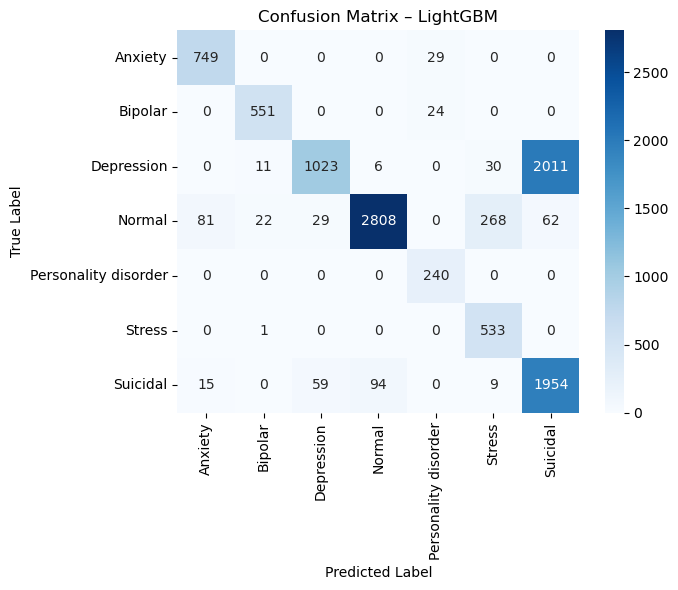

In [12]:
# Predict on test data
y_pred = lgbm.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – LightGBM")
plt.tight_layout()
plt.show()


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


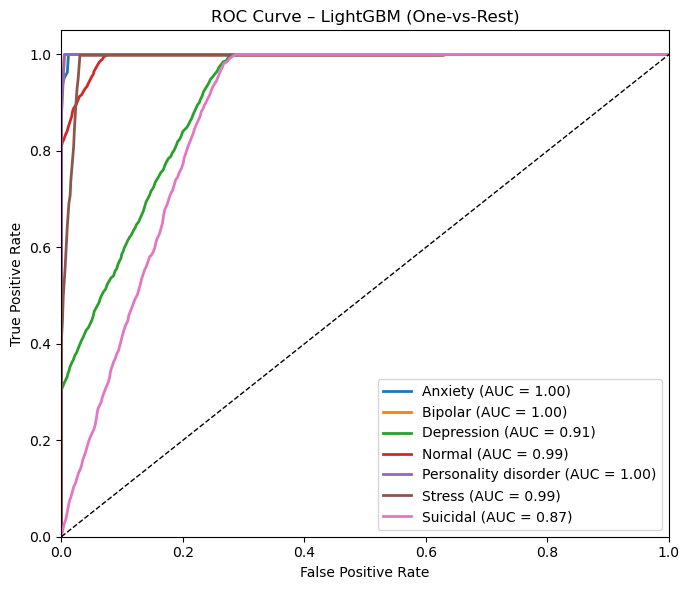

In [13]:
# Number of classes
n_classes = len(label_encoder.classes_)

# Get prediction probabilities
y_proba = lgbm.predict_proba(X_test)

# Binarize the true labels
y_test_bin = label_binarize(y_test, classes=range(n_classes))

plt.figure(figsize=(7, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})"
    )

# Diagonal reference line
plt.plot([0, 1], [0, 1], "k--", lw=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – LightGBM (One-vs-Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


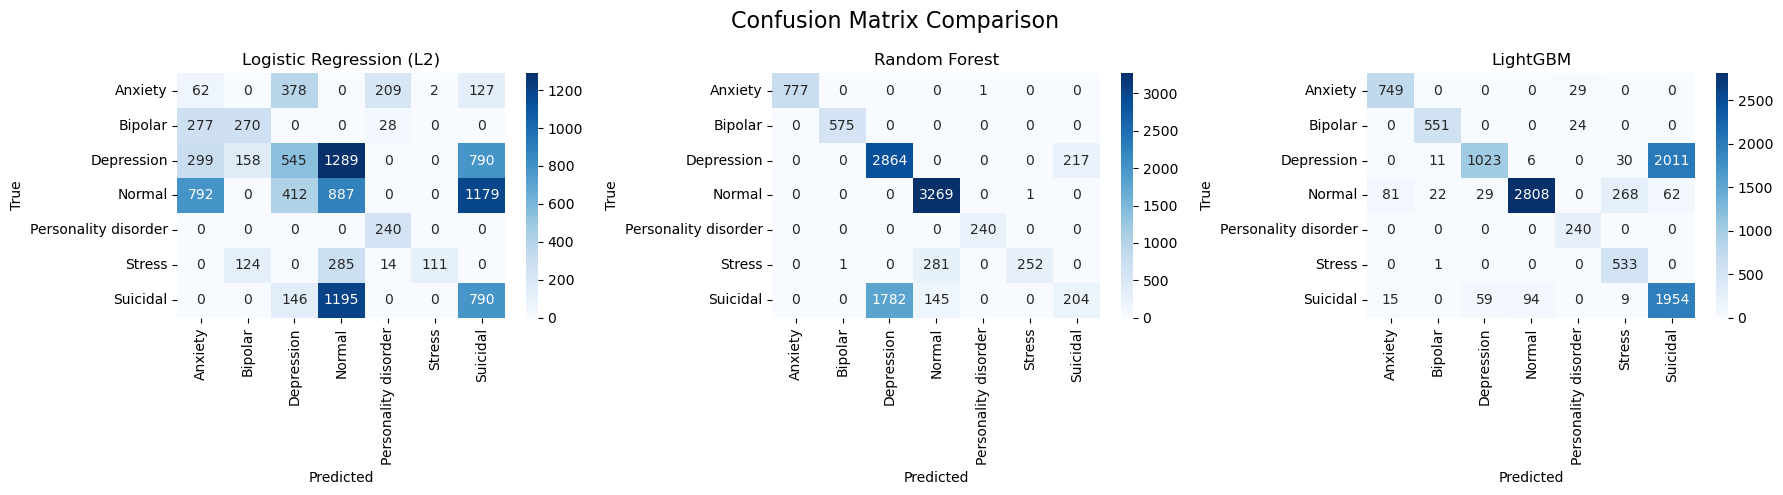

In [15]:
models = {
    "Logistic Regression (L2)": log_reg,
    "Random Forest": rf,
    "LightGBM": lgbm
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
        ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Confusion Matrix Comparison", fontsize=16)
plt.tight_layout()
plt.show()


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


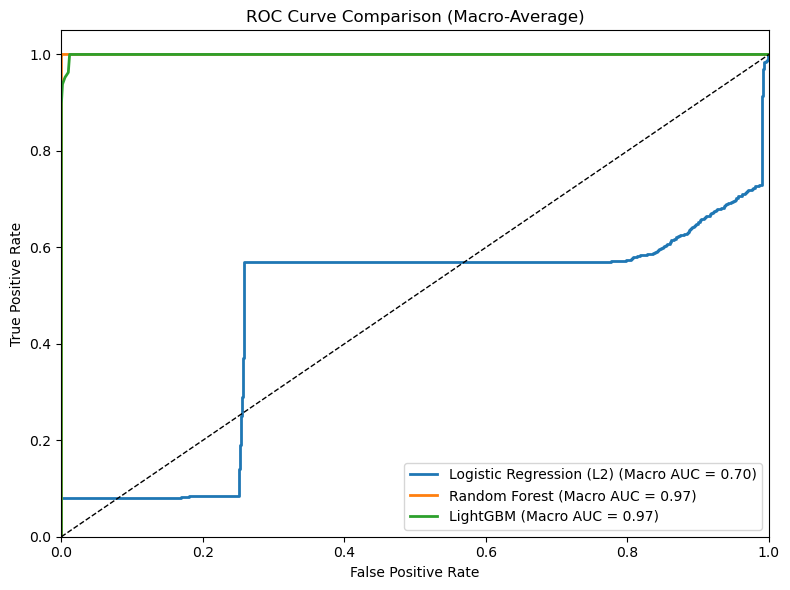

In [16]:
n_classes = len(label_encoder.classes_)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)

    # Macro-average ROC
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    macro_auc = np.mean(list(roc_auc.values()))

    plt.plot(
        fpr[0],
        tpr[0],
        lw=2,
        label=f"{name} (Macro AUC = {macro_auc:.2f})"
    )

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Macro-Average)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
